In [2]:
from typing import Optional

import numpy as np

import torch
import torchopt

import nll_to_po.models.dn_policy as Policy
import nll_to_po.models.reward_network as RM
from nll_to_po.training.utils import (
    set_seed_everywhere,
)
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
sns.set_palette("colorblind")
sns.despine()

<Figure size 640x480 with 0 Axes>

### Data utils

In [3]:
def generate_data_linear(
    input_dim: int,
    output_dim: int,
    train_size: int = 100,
    val_size: int = 100,
    test_size: int = 100,
    init_dist_loc: Optional[float] = None,
    init_dist_scale: Optional[float] = None,
    init_dist_n_samples: int = 1,
    A: Optional[torch.Tensor] = None,
):
    assert input_dim == output_dim, (
        f"input dim {input_dim} is different from output dim {output_dim}"
    )

    set_seed_everywhere(seed=np.random.randint(0, 1e6))

    # resample parameters
    if A is None:
        A = torch.eye(output_dim)
    if init_dist_loc is None:
        init_dist_loc = np.random.uniform(-6.0, 6.0)
    if init_dist_scale is None:
        init_dist_scale = np.random.uniform(0.1, 2.5)

    # Generate input data (uniform in -5,5)
    X_unique = torch.rand((train_size + val_size + test_size, input_dim)) * 10 - 5

    # For training data: repeat each unique X multiple times
    X_train_unique = X_unique[:train_size]
    X_train = X_train_unique.repeat_interleave(init_dist_n_samples, dim=0)

    # Compute mean for training X and sample multiple y values
    mean_y_train = X_train_unique @ A.T + init_dist_loc
    mean_y_train_expanded = mean_y_train.repeat_interleave(init_dist_n_samples, dim=0)
    y_train = (
        mean_y_train_expanded
        + torch.randn(X_train.shape[0], output_dim) * init_dist_scale
    )
    std_y_train = torch.full_like(mean_y_train_expanded, init_dist_scale)

    # For validation data: use unique X without repetition
    X_val = X_unique[train_size : train_size + val_size]
    mean_y_val = X_val @ A.T + init_dist_loc
    y_val = mean_y_val + torch.randn(X_val.shape[0], output_dim) * init_dist_scale
    std_y_val = torch.full_like(mean_y_val, init_dist_scale)

    # For test data: use unique X without repetition
    X_test = X_unique[train_size + val_size :]
    mean_y_test = X_test @ A.T + init_dist_loc
    y_test = mean_y_test + torch.randn(X_test.shape[0], output_dim) * init_dist_scale
    std_y_test = torch.full_like(mean_y_test, init_dist_scale)

    # Create DataLoaders
    train_dataset = torch.utils.data.TensorDataset(
        X_train, y_train, mean_y_train_expanded, std_y_train
    )
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=X_train.shape[0], shuffle=True
    )
    val_dataset = torch.utils.data.TensorDataset(X_val, y_val, mean_y_val, std_y_val)
    val_dataloader = torch.utils.data.DataLoader(
        val_dataset, batch_size=X_val.shape[0], shuffle=False
    )
    test_dataset = torch.utils.data.TensorDataset(
        X_test, y_test, mean_y_test, std_y_test
    )
    test_dataloader = torch.utils.data.DataLoader(
        test_dataset, batch_size=X_test.shape[0], shuffle=False
    )

    return (
        train_dataloader,
        val_dataloader,
        test_dataloader,
        {
            "init_dist_loc": init_dist_loc,
            "init_dist_scale": init_dist_scale,
            "init_dist_n_samples": init_dist_n_samples,
        },
    )


def generate_data_single_point(
    input_dim: int,
    output_dim: int,
    init_dist_loc: Optional[float] = None,
    init_dist_scale: Optional[float] = None,
    init_dist_n_samples: Optional[int] = None,
):
    set_seed_everywhere(seed=np.random.randint(0, 1e6))

    # resample parameters
    if not init_dist_loc:
        init_dist_loc = np.random.uniform(-5.0, 5.0)
    if not init_dist_scale:
        init_dist_scale = np.random.uniform(0.5, 1.5)
    if not init_dist_n_samples:
        init_dist_n_samples = np.random.randint(1, 100)

    # Generate new random data for each experiment
    X = torch.randn(1, input_dim)
    mean_y = torch.ones((1, output_dim)) * init_dist_loc
    mean_y_expanded = mean_y.repeat_interleave(init_dist_n_samples, dim=0)
    y = mean_y_expanded + torch.randn(init_dist_n_samples, output_dim) * init_dist_scale
    X = X.repeat(init_dist_n_samples, 1)  # Repeat X for each sample
    batch_size = X.shape[0]
    std_y = torch.full_like(mean_y_expanded, init_dist_scale)

    # Create a DataLoader
    train_dataset = torch.utils.data.TensorDataset(X, y, mean_y_expanded, std_y)
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    return (
        train_dataloader,
        None,
        None,
        {
            "init_dist_loc": init_dist_loc,
            "init_dist_scale": init_dist_scale,
            "init_dist_n_samples": init_dist_n_samples,
        },
    )

### Generate data, policy, and reward network

##### Params

In [4]:
# Experiment parameters
n_experiments: int = 10
n_updates: int = 100
learning_rate: float = 0.01

# Policy architecture
input_dim: int = 2
output_dim: int = 2
hidden_sizes: list[int] = [64, 64]
fixed_logstd: bool = False

# Data generating dist q
single_point: bool = False
generate_new_params_per_exp: bool = True

init_dist_loc: float = 6.0
init_dist_scale: float = 1.75
init_dist_n_samples: int = 10

##### Data

In [5]:
if single_point:
    train_dataloader, val_dataloader, test_dataloader, data_config = (
        generate_data_single_point(
            input_dim=input_dim,
            output_dim=output_dim,
            init_dist_loc=init_dist_loc,
            init_dist_scale=init_dist_scale,
            init_dist_n_samples=init_dist_n_samples,
        )
    )
else:
    train_size: int = 100
    val_size: int = 100
    # A: torch.Tensor = torch.randn((output_dim, input_dim))
    A: torch.Tensor = torch.eye(output_dim)

    train_dataloader, val_dataloader, test_dataloader, data_config = (
        generate_data_linear(
            input_dim=input_dim,
            output_dim=output_dim,
            train_size=train_size,
            val_size=val_size,
            init_dist_loc=init_dist_loc,
            init_dist_scale=init_dist_scale,
            init_dist_n_samples=init_dist_n_samples,
            A=A,
        )
    )

##### Models

In [6]:
# policy = Policy.LinearGaussian(input_dim, output_dim, fixed_logstd)
policy = Policy.MLPPolicy(input_dim, output_dim, hidden_sizes, fixed_logstd)
reward_network = RM.RewardMLP(input_dim, hidden_sizes)

reward_fn = R.RewardNetwork(reward_network=reward_network)

pg_loss = L.FuncPG(
    reward_fn=reward_fn,
    n_generations=5,
    use_rsample=False,
    reward_transform="none",  # "normalize", "rbf", "none"
    entropy_weight=0.1,
    clip_coef=None,
)
nll_loss = L.FuncNLL()

### Torchopt

In [11]:
# -----------------------
# Helper: make functional params with grad
# -----------------------
def make_functional_with_grads(module):
    params = dict(module.named_parameters())
    params = [p.detach().clone().requires_grad_(True) for _, p in params.items()]
    return module, params


# -----------------------
# Main bilevel routine
# -----------------------
def run_bilevel_optimization(
    n_outer_epochs=10,
    n_inner_epochs=5,
    inner_lr: float = 1e-3,
    outer_lr: float = 1e-3,
    device: str = "cpu",
):
    # Build reward network once
    # reward_network = RM.RewardMLP(input_dim, hidden_sizes).to(device)
    reward_network = RM.RewardMLPMahalanobis(input_dim).to(device)
    # reward_model, reward_params = make_functional_with_grads(reward_network)

    # reward_fn = R.FuncRewardNetwork(
    #     reward_model=reward_model, reward_params=reward_params
    # )
    reward_fn = R.RewardNetwork(
        reward_network=reward_network,
    )

    pg_loss = L.FuncPG(
        reward_fn=reward_fn,
        n_generations=5,
        use_rsample=False,
        reward_transform="none",
        entropy_weight=0.1,
        clip_coef=None,
    )
    nll_loss = L.FuncNLL()

    # Tracking
    outer_losses = []
    inner_losses_per_outer = []

    # Outer optimizer
    reward_opt = torch.optim.Adam(reward_network.parameters(), lr=outer_lr)

    def inner_loss_fn(policy_params, X, y, mu, std):
        loss, _ = pg_loss.compute_loss(
            policy_model,
            policy_params,
            X,
            y,
            mu,
            std,
            reward_network=reward_network,  # reward_params=reward_params
        )
        return loss

    for outer_epoch in range(n_outer_epochs):
        # Reset policy each outer iteration
        policy = Policy.MLPPolicy(input_dim, output_dim, hidden_sizes, fixed_logstd).to(
            device
        )
        policy_model, policy_params = make_functional_with_grads(policy)

        # Convert to torchopt format
        # policy_params_list = list(policy_params.values())

        # Create differentiable SGD optimizer
        inner_optimizer = torchopt.sgd(lr=inner_lr)
        inner_opt_state = inner_optimizer.init(policy_params)

        inner_losses = []

        # Inner loop with torchopt
        for inner_step in range(n_inner_epochs):
            for X, y, mu, std in train_dataloader:
                X, y, mu, std = (
                    X.to(device),
                    y.to(device),
                    mu.to(device),
                    std.to(device),
                )
                # Reconstruct params dict (for functional_call)
                policy_params_dict = dict(
                    zip(dict(policy_model.named_parameters()).keys(), policy_params)
                )

                # Compute gradients and update
                grads = torch.func.grad(inner_loss_fn)(
                    policy_params_dict,
                    X,
                    y,
                    mu,
                    std,
                )
                updates, inner_opt_state = inner_optimizer.update(
                    grads, inner_opt_state, inplace=False
                )
                policy_params_dict = torchopt.apply_updates(policy_params_dict, updates)
                policy_params = list(policy_params_dict.values())

                # Track loss
                with torch.no_grad():
                    inner_loss, _ = pg_loss.compute_loss(
                        policy_model,
                        policy_params_dict,
                        X,
                        y,
                        mu,
                        std,
                        reward_network=reward_network,  # reward_params=reward_params
                    )
                    inner_losses.append(float(inner_loss))

        # Convert back to dict format for outer loss
        # final_policy_params = dict(
        #     zip(dict(policy_model.named_parameters()).keys(), policy_params)
        # )

        # -----------------------
        # Outer loop: update reward params
        # -----------------------
        reward_opt.zero_grad(set_to_none=True)

        outer_loss_accum = 0.0
        batch_count = 0

        for X, y, mu, std in train_dataloader:
            X, y, mu, std = X.to(device), y.to(device), mu.to(device), std.to(device)
            outer_loss, _ = nll_loss.compute_loss(
                policy_model, policy_params_dict, X, y, mu, std
            )
            outer_loss_accum = outer_loss_accum + outer_loss
            batch_count += 1

        if batch_count > 0:
            outer_loss_accum = outer_loss_accum / batch_count

        outer_loss_accum.backward()
        reward_opt.step()

        outer_losses.append(float(outer_loss_accum.detach()))
        inner_losses_per_outer.append(inner_losses)

        print(f"Outer epoch {outer_epoch}: Outer loss = {outer_loss_accum.item():.4f}")
        print("Inner losses =", [f"{il:.4f}" for il in inner_losses])

        # After updating, make sure reward params remain leaf tensors
        # reward_params = [p.detach().clone().requires_grad_(True) for p in reward_params]

    return outer_losses, inner_losses_per_outer

Outer epoch 0: Outer loss = 57.9533
Inner losses = ['-123.6683', '-117.0515', '-113.5252', '-109.5522', '-106.4552', '-103.2276', '-100.3288', '-99.2519', '-95.9247', '-92.6237', '-90.3639', '-86.4523', '-83.5732', '-80.7365', '-76.1615', '-71.8493', '-68.4752', '-64.6685', '-60.6011', '-57.3010', '-54.0592', '-50.1246', '-47.2419', '-44.2664', '-41.0146', '-37.4989', '-35.6957', '-34.6593', '-32.8053', '-29.7776', '-27.9623', '-26.4137', '-25.6755', '-22.8323', '-20.6242', '-20.3994', '-18.4879', '-17.4644', '-16.7303', '-15.2778', '-14.4756', '-13.6195', '-13.5555', '-13.0419', '-12.4803', '-11.8546', '-11.3150', '-11.1357', '-10.7192', '-10.4770', '-10.6128', '-10.5153', '-9.5487', '-9.5346', '-8.5214', '-8.5517', '-8.2954', '-8.2486', '-8.0208', '-7.9957', '-7.5793', '-7.3047', '-7.1329', '-6.8081', '-6.8829', '-7.1431', '-6.8491', '-6.5418', '-6.6131', '-5.8680', '-5.4074', '-5.6352', '-5.6328', '-4.6213', '-5.0350', '-5.1167', '-5.1546', '-4.9683', '-4.9596', '-4.9616', '-5.0740'

/tmp/ipykernel_848863/3433943979.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


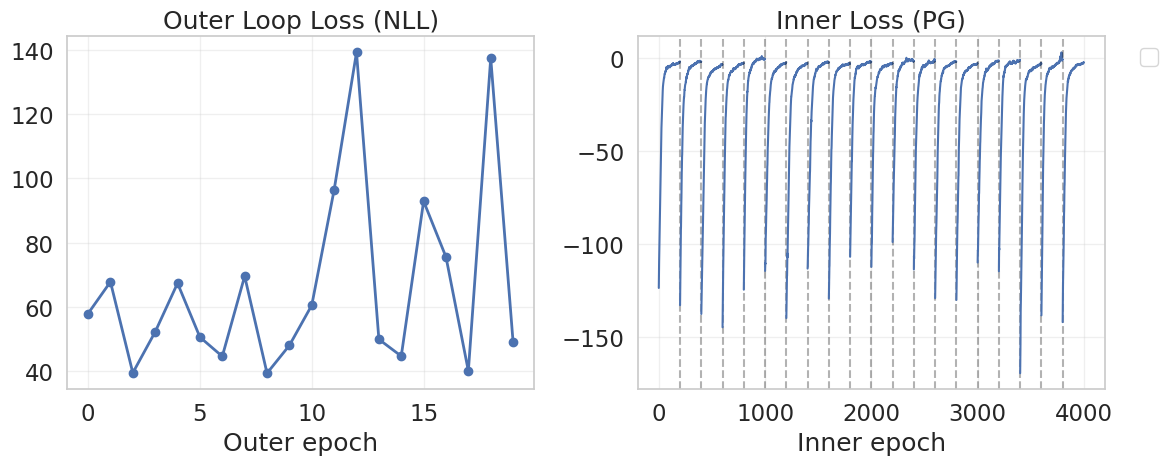

In [15]:
# Run the bilevel optimization
outer_losses, inner_losses_per_outer = run_bilevel_optimization(
    n_outer_epochs=20, n_inner_epochs=200, inner_lr=1e-3, outer_lr=1e-2, device="cuda:0"
)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot outer losses
ax1.plot(outer_losses, "b-o", linewidth=2, markersize=6)
ax1.set_xlabel("Outer epoch")
ax1.set_title("Outer Loop Loss (NLL)")
ax1.grid(True, alpha=0.3)

# Plot inner losses
for i, inner_losses in enumerate(inner_losses_per_outer):
    epochs = [i * len(inner_losses) + j for j in range(len(inner_losses))]
    ax2.plot(epochs, inner_losses, "b")

    # Add vertical dotted line at the end of each segment
    if i < len(inner_losses_per_outer) - 1:  # Don't add line after the last segment
        ax2.axvline(x=epochs[-1] + 0.5, color="black", linestyle="--", alpha=0.3)

ax2.set_xlabel("Inner epoch")
ax2.set_title("Inner Loss (PG)")
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()